# Workshop Part 4: ML Analysis (Data Analyst)

## Learning Objectives
- Train a sentiment analysis model using scikit-learn
- Evaluate model performance
- Use the model to make predictions
- Create a discount recommendation system
- Save the trained model for deployment

## Two Types of Analysis

1. **Analyze Output Model**: Evaluate how well our sentiment classifier performs
2. **Analyze "Why"**: Understand why products get certain sentiments

## Use Case Selection

**Day-to-day (PowerBI)**: Questions and analysis from business
- "Which products have the worst sentiment?"
- "How does sentiment change over time?"
- "Which stores have the most negative reviews?"

**Python for Debugging**: When something goes wrong or deep analysis needed
- Model performance issues
- Data quality investigation
- Custom analysis not possible in BI tools

In [35]:
# Workshop Progress Tracker
notebooks = ["01 Extract", "02 Prepare", "03 Storage", "04 ML", "05 Deploy"]
current = 3  # This is notebook 04

print("="*70)
print("📊 WORKSHOP PROGRESS")
print("="*70)
for i, nb in enumerate(notebooks):
    if i < current:
        print(f"✅ {nb}")
    elif i == current:
        print(f"👉 {nb} ← YOU ARE HERE")
    else:
        print(f"⬜ {nb}")
print("="*70)

📊 WORKSHOP PROGRESS
✅ 01 Extract
✅ 02 Prepare
✅ 03 Storage
👉 04 ML ← YOU ARE HERE
⬜ 05 Deploy


## Step 1: Load Cleaned Data

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('../data/cleaned/cleaned_reviews.csv')

print(f"Loaded {len(df)} reviews")
print(f"Sentiment distribution:")
print(df['sentiment'].value_counts())

Loaded 740 reviews
Sentiment distribution:
sentiment
positive    441
neutral     192
negative    107
Name: count, dtype: int64


## Step 2: Split Data (Train/Test)

**Why split the data?**
- **Training set (80%)**: Used to train the model
- **Test set (20%)**: Used to evaluate performance on unseen data
- Prevents overfitting and gives realistic performance estimates

In [37]:
# Features (X) and target (y)
X = df['review_text_clean']
y = df['sentiment']

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} reviews")
print(f"Test set: {len(X_test)} reviews")
print(f"\nTraining set sentiment distribution:")
print(y_train.value_counts())

Training set: 592 reviews
Test set: 148 reviews

Training set sentiment distribution:
sentiment
positive    353
neutral     154
negative     85
Name: count, dtype: int64


## Step 3: Text Vectorization (TF-IDF)

**What is TF-IDF?**
- **TF (Term Frequency)**: How often a word appears in a document
- **IDF (Inverse Document Frequency)**: How unique/important a word is across all documents
- Converts text into numerical features for ML

Example:
- "best" appears often in positive reviews → high TF-IDF for positive sentiment
- "worst" appears often in negative reviews → high TF-IDF for negative sentiment
- Common words like "the", "is" → low TF-IDF (not discriminative)

In [38]:
# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=500,  # Use top 500 most important words
    min_df=2,  # Word must appear in at least 2 documents
    max_df=0.9,  # Ignore words that appear in >90% of documents
    ngram_range=(1, 2)  # Use single words and two-word phrases
)

# Fit on training data and transform both train and test
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"TF-IDF feature shape: {X_train_tfidf.shape}")
print(f"Number of features (words/phrases): {len(vectorizer.get_feature_names_out())}")
print(f"\nTop 20 features:")
print(vectorizer.get_feature_names_out()[:20])

TF-IDF feature shape: (592, 341)
Number of features (words/phrases): 341

Top 20 features:
['about' 'acceptable' 'again' 'all' 'alright' 'alright nothing' 'always'
 'always consistent' 'amazing' 'amazing quality' 'and' 'and delicious'
 'and disappointing' 'and not' 'and tasteless' 'and tasty' 'and very'
 'are' 'are acceptable' 'are alright']


## Step 4: Train Sentiment Analysis Model

We'll use **Logistic Regression** - a simple but effective classifier for text.

**How it works:**
- Learns weights for each word/phrase
- Positive words ("best", "fresh") → positive weight
- Negative words ("worst", "stale") → negative weight
- Combines weights to predict sentiment

In [39]:
# Train Logistic Regression classifier
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # Handle class imbalance
)

print("Training model...")
model.fit(X_train_tfidf, y_train)
print("Model trained successfully!")

Training model...
Model trained successfully!


## Step 5: Evaluate Model Performance

### Analyze Output Model
How well does our sentiment classifier perform?

In [40]:
# Make predictions on test set
y_pred = model.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred))

Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        22
     neutral       1.00      1.00      1.00        38
    positive       1.00      1.00      1.00        88

    accuracy                           1.00       148
   macro avg       1.00      1.00      1.00       148
weighted avg       1.00      1.00      1.00       148



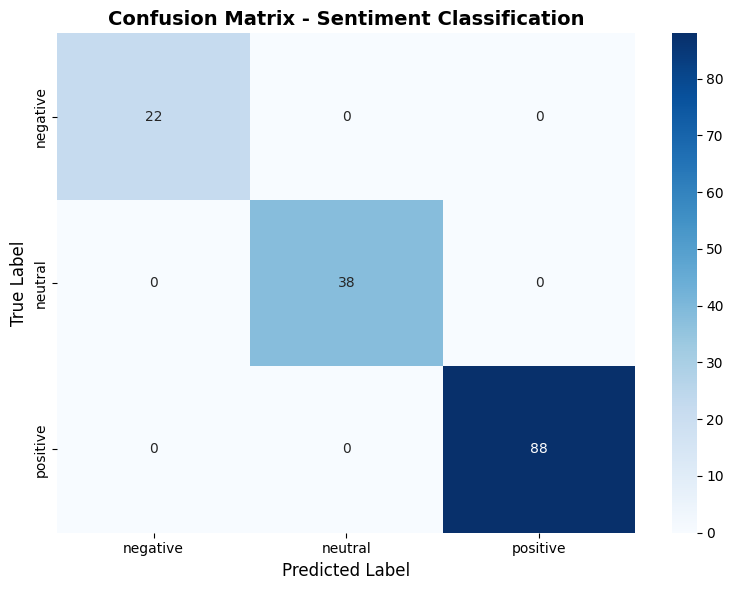


Confusion Matrix Interpretation:
- Diagonal values (correct predictions): Higher is better
- Off-diagonal values (mistakes): Lower is better


In [41]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('Confusion Matrix - Sentiment Classification', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Interpretation:")
print("- Diagonal values (correct predictions): Higher is better")
print("- Off-diagonal values (mistakes): Lower is better")

## Step 6: Analyze "Why" - Most Important Words

Let's see which words are most predictive for each sentiment.

In [42]:
# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Get class labels and coefficients
classes = model.classes_
coefficients = model.coef_

# Show top words for each sentiment
n_top = 10

for i, sentiment in enumerate(classes):
    print(f"\n{'='*60}")
    print(f"Top {n_top} words for '{sentiment.upper()}' sentiment:")
    print(f"{'='*60}")
    
    # Get indices of top features
    top_indices = coefficients[i].argsort()[-n_top:][::-1]
    
    for idx in top_indices:
        word = feature_names[idx]
        weight = coefficients[i][idx]
        print(f"  {word:20s} (weight: {weight:+.3f})")


Top 10 words for 'NEGATIVE' sentiment:
  were                 (weight: +1.572)
  poor                 (weight: +1.418)
  poor quality         (weight: +1.418)
  not                  (weight: +1.229)
  not fresh            (weight: +0.992)
  with these           (weight: +0.971)
  disappointed         (weight: +0.971)
  very disappointed    (weight: +0.971)
  with                 (weight: +0.971)
  disappointed with    (weight: +0.971)

Top 10 words for 'NEUTRAL' sentiment:
  standard quality     (weight: +1.404)
  standard             (weight: +1.404)
  are                  (weight: +1.400)
  fair                 (weight: +1.264)
  fair quality         (weight: +1.264)
  decent               (weight: +1.244)
  are okay             (weight: +1.105)
  okay                 (weight: +1.105)
  are acceptable       (weight: +1.084)
  acceptable           (weight: +1.084)

Top 10 words for 'POSITIVE' sentiment:
  my                   (weight: +1.315)
  quality these        (weight: +1.288)
 

### 🔍 OPTIONAL CHALLENGE: Become a Model Detective!

**For Advanced Students:** Can you fool the model?

In [43]:
# Optional challenge for advanced students
print("="*70)
print("🔍 OPTIONAL CHALLENGE: Become a Model Detective!")
print("="*70)
print("\n🎯 CHALLENGE: Can you fool the model?")
print("\nTask: Write a review that SOUNDS positive but gets classified as negative")
print("(or vice versa)")
print("\nExample: 'This spinach is not bad' ← sounds neutral but might confuse model")
print("\n💡 Bonus points if you can explain WHY the model got confused!")
print("\nTry it in the prediction cell above, then discuss with neighbors.")
print("-"*70)
print("\n🤔 Think about:")
print("   • Negations: 'not bad' vs 'good'")
print("   • Sarcasm: 'Oh great, another stale carrot'")
print("   • Mixed signals: 'Fresh but tasteless'")
print("\n⏰ This is optional - skip if short on time!")

🔍 OPTIONAL CHALLENGE: Become a Model Detective!

🎯 CHALLENGE: Can you fool the model?

Task: Write a review that SOUNDS positive but gets classified as negative
(or vice versa)

Example: 'This spinach is not bad' ← sounds neutral but might confuse model

💡 Bonus points if you can explain WHY the model got confused!

Try it in the prediction cell above, then discuss with neighbors.
----------------------------------------------------------------------

🤔 Think about:
   • Negations: 'not bad' vs 'good'
   • Sarcasm: 'Oh great, another stale carrot'
   • Mixed signals: 'Fresh but tasteless'

⏰ This is optional - skip if short on time!


## Step 7: Make Predictions on New Reviews

Let's test our model with some example reviews.

In [44]:
def predict_sentiment(review_text):
    """
    Predict sentiment for a review text
    """
    # Preprocess text (same as training)
    import re
    text_clean = review_text.lower()
    text_clean = ' '.join(text_clean.split())
    text_clean = re.sub(r'[^a-z\s.,!?]', '', text_clean)
    
    # Vectorize
    text_tfidf = vectorizer.transform([text_clean])
    
    # Predict
    sentiment = model.predict(text_tfidf)[0]
    probabilities = model.predict_proba(text_tfidf)[0]
    
    return sentiment, probabilities

# Test with example reviews
test_reviews = [
    "This is the worst spinach ever! Not fresh at all.",
    "Best potatoes in my life! Super fresh and delicious.",
    "The carrot was a bit stale and disappointing.",
    "These tomatoes are okay, nothing special."
]

print("Test Predictions:")
print("="*80)

for review in test_reviews:
    sentiment, probs = predict_sentiment(review)
    print(f"\nReview: {review}")
    print(f"Predicted Sentiment: {sentiment.upper()}")
    print(f"Confidence: {probs.max():.1%}")
    print(f"Probabilities: Negative={probs[0]:.2%}, Neutral={probs[1]:.2%}, Positive={probs[2]:.2%}")

Test Predictions:

Review: This is the worst spinach ever! Not fresh at all.
Predicted Sentiment: NEGATIVE
Confidence: 88.5%
Probabilities: Negative=88.45%, Neutral=5.71%, Positive=5.84%

Review: Best potatoes in my life! Super fresh and delicious.
Predicted Sentiment: POSITIVE
Confidence: 89.3%
Probabilities: Negative=5.68%, Neutral=5.04%, Positive=89.28%

Review: The carrot was a bit stale and disappointing.
Predicted Sentiment: NEGATIVE
Confidence: 90.7%
Probabilities: Negative=90.73%, Neutral=3.88%, Positive=5.39%

Review: These tomatoes are okay, nothing special.
Predicted Sentiment: NEUTRAL
Confidence: 92.7%
Probabilities: Negative=2.69%, Neutral=92.70%, Positive=4.61%


**💡 Group Challenge:** Who can write a review that gets a 90% discount? Try it and discuss with your neighbor - why did certain words trigger such a high discount?

### 🎮 YOUR TURN: Interactive Prediction Station!

Now it's your turn to test the model! Try typing your own product reviews and see what happens.

In [45]:
# Interactive prediction cell
print("="*70)
print("🎮 YOUR TURN: Test the Sentiment Analysis Model!")
print("="*70)
print("\nModify the review below and re-run this cell to test different reviews!")
print("Tip: Try being very positive or very negative to see extreme results\n")

# ✏️ EDIT THIS: Change the review text and re-run the cell!
user_review = "This is the worst spinach ever! Not fresh at all."

# Predict sentiment
sentiment, probs = predict_sentiment(user_review)
confidence = probs.max()

# Fun emoji based on sentiment
emoji = {'positive': '😊', 'neutral': '😐', 'negative': '😠'}[sentiment]

print("-"*70)
print(f"📝 Your Review: \"{user_review}\"")
print(f"\n   {emoji} Sentiment: {sentiment.upper()}")
print(f"   📊 Confidence: {confidence:.0%}")
print(f"   💰 Probabilities:")
print(f"      Negative: {probs[0]:.1%} | Neutral: {probs[1]:.1%} | Positive: {probs[2]:.1%}")

# Calculate discount
if sentiment == 'negative':
    discount = 70 + int((confidence - 0.6) * 50) if confidence >= 0.6 else 50
elif sentiment == 'neutral':
    discount = 25
else:
    discount = 5
discount = min(discount, 90)

print(f"   🎯 Recommended Discount: {discount}%")

if discount >= 70:
    print(f"   💥 WOW! That's a major discount! Product needs attention!")
elif discount <= 10:
    print(f"   ✨ Great review! Product is selling itself!")

print("="*70)
print("\n💡 TIP: Edit the 'user_review' text above and re-run this cell!")
print("\nTry these examples:")
print("  • 'Best potatoes in my life! Super fresh and delicious.'")
print("  • 'The carrot was okay, nothing special'")
print("  • 'Terrible quality, very disappointed with these tomatoes'")

🎮 YOUR TURN: Test the Sentiment Analysis Model!

Modify the review below and re-run this cell to test different reviews!
Tip: Try being very positive or very negative to see extreme results

----------------------------------------------------------------------
📝 Your Review: "This is the worst spinach ever! Not fresh at all."

   😠 Sentiment: NEGATIVE
   📊 Confidence: 88%
   💰 Probabilities:
      Negative: 88.5% | Neutral: 5.7% | Positive: 5.8%
   🎯 Recommended Discount: 84%
   💥 WOW! That's a major discount! Product needs attention!

💡 TIP: Edit the 'user_review' text above and re-run this cell!

Try these examples:
  • 'Best potatoes in my life! Super fresh and delicious.'
  • 'The carrot was okay, nothing special'
  • 'Terrible quality, very disappointed with these tomatoes'


**💬 Group Discussion (2 minutes):**
- Would you approve this discount strategy as a manager?
- How could we optimize to reduce cost while keeping customers happy?
- What if we only applied discounts to products with >20% negative sentiment?

In [46]:
# Make the business impact tangible
print("="*70)
print("💰 BUSINESS IMPACT: What if we apply these discounts?")
print("="*70)

# Simulate business metrics
avg_product_price = 2.50  # euros
avg_sales_per_day = 100   # units per product

print(f"\n📊 ASSUMPTIONS:")
print(f"   Average product price: €{avg_product_price}")
print(f"   Average daily sales: {avg_sales_per_day} units per product")

# Calculate for each product
print(f"\n💸 ESTIMATED DAILY DISCOUNT COSTS:")
print("-"*70)

total_daily_cost = 0
for product in df['product_name'].unique():
    product_reviews = df[df['product_name'] == product]
    avg_sentiment_discount = product_reviews.apply(
        lambda row: 70 if row['sentiment'] == 'negative'
                   else 25 if row['sentiment'] == 'neutral'
                   else 5,
        axis=1
    ).mean()
    
    # Estimate cost
    daily_discount_cost = avg_product_price * avg_sales_per_day * (avg_sentiment_discount / 100)
    monthly_cost = daily_discount_cost * 30
    total_daily_cost += daily_discount_cost
    
    print(f"{product:15} | Avg Discount: {avg_sentiment_discount:5.1f}% | "
          f"Daily Cost: €{daily_discount_cost:6.2f} | Monthly: €{monthly_cost:7.2f}")

total_monthly = total_daily_cost * 30

print("="*70)
print(f"📈 TOTAL MONTHLY DISCOUNT BUDGET: €{total_monthly:,.2f}")
print(f"   Per product per day: €{total_daily_cost / len(df['product_name'].unique()):.2f}")
print(f"\n💡 DISCUSSION: Is this cost worth it to reduce food waste?")

💰 BUSINESS IMPACT: What if we apply these discounts?

📊 ASSUMPTIONS:
   Average product price: €2.5
   Average daily sales: 100 units per product

💸 ESTIMATED DAILY DISCOUNT COSTS:
----------------------------------------------------------------------
Tomatoes        | Avg Discount:  19.8% | Daily Cost: € 49.39 | Monthly: €1481.71
Potatoes        | Avg Discount:  19.5% | Daily Cost: € 48.67 | Monthly: €1459.95
Broccoli        | Avg Discount:  19.5% | Daily Cost: € 48.77 | Monthly: €1463.03
Carrots         | Avg Discount:  19.3% | Daily Cost: € 48.31 | Monthly: €1449.15
Lettuce         | Avg Discount:  17.3% | Daily Cost: € 43.37 | Monthly: €1301.14
Spinach         | Avg Discount:  22.3% | Daily Cost: € 55.74 | Monthly: €1672.13
📈 TOTAL MONTHLY DISCOUNT BUDGET: €8,827.11
   Per product per day: €49.04

💡 DISCUSSION: Is this cost worth it to reduce food waste?


## 🎯 Quick Recap: Test Your Understanding

Take a couple minutes to discuss these questions with your neighbor:

In [47]:
print("="*70)
print("🎯 QUICK RECAP: Test Your Understanding")
print("="*70)
print("\n❓ DISCUSSION QUESTIONS (Talk with your neighbor for 2 minutes):")
print("\n1. In your own words: What does the sentiment model do?")
print("   Hint: Input → ... → Output")
print("\n2. Why is 'poor' a strong predictor of negative sentiment?")
print("   Hint: Look at the word weights we saw earlier.")
print("\n3. Would you use this model in production at Albert Heijn? Why or why not?")
print("   Hint: Think about accuracy, speed, and business impact.")
print("\n4. What could go wrong if we give 90% discount to every negative review?")
print("   Hint: Consider costs, potential gaming of the system.")
print("\n✅ Amazing work! Let's move to Notebook 05: Deployment Theory!")
print("="*70)

🎯 QUICK RECAP: Test Your Understanding

❓ DISCUSSION QUESTIONS (Talk with your neighbor for 2 minutes):

1. In your own words: What does the sentiment model do?
   Hint: Input → ... → Output

2. Why is 'poor' a strong predictor of negative sentiment?
   Hint: Look at the word weights we saw earlier.

3. Would you use this model in production at Albert Heijn? Why or why not?
   Hint: Think about accuracy, speed, and business impact.

4. What could go wrong if we give 90% discount to every negative review?
   Hint: Consider costs, potential gaming of the system.

✅ Amazing work! Let's move to Notebook 05: Deployment Theory!


## Step 8: Discount Recommendation System

Now let's create the discount recommendation logic!

### Discount Rules:
- **Negative sentiment (1-2 stars)**: 50-90% discount
- **Neutral sentiment (3 stars)**: 20-30% discount
- **Positive sentiment (4-5 stars)**: 0-10% discount

We'll also consider:
- Confidence of the prediction (higher confidence → more extreme discount)
- Sales volume (lower sales + negative sentiment → higher discount)

**💬 Group Discussion (2 minutes):**
- Which product would you focus on first as a store manager?
- Why might certain products have more negative reviews? (Think: perishability, freshness, storage)

In [48]:
# Create a fun leaderboard
print("="*70)
print("🏆 PRODUCT SENTIMENT LEADERBOARD 🏆")
print("="*70)

# Calculate sentiment scores (weighted)
product_stats_lb = df.groupby('product_name').agg({
    'sentiment': [
        ('negative_pct', lambda x: (x == 'negative').mean() * 100),
        ('positive_pct', lambda x: (x == 'positive').mean() * 100),
        ('total_reviews', 'count')
    ],
    'rating': 'mean'
}).round(1)

# Flatten columns
product_stats_lb.columns = ['_'.join(col) for col in product_stats_lb.columns]
product_stats_lb = product_stats_lb.reset_index()

# Create overall score (0-100, higher is better)
product_stats_lb['happiness_score'] = (
    product_stats_lb['sentiment_positive_pct'] -
    product_stats_lb['sentiment_negative_pct']
)

# Sort and rank
product_stats_lb = product_stats_lb.sort_values('happiness_score', ascending=False)
product_stats_lb['rank'] = range(1, len(product_stats_lb) + 1)

# Display with fun formatting
print("\n🥇 HAPPIEST PRODUCTS (Customer Loves Them)")
print("-"*70)
for _, row in product_stats_lb.head(3).iterrows():
    emoji = "🥇" if row['rank'] == 1 else "🥈" if row['rank'] == 2 else "🥉"
    print(f"{emoji} #{int(row['rank'])} {row['product_name']:15} | "
          f"Happiness Score: {row['happiness_score']:+.1f} | "
          f"⭐ {row['rating_mean']:.1f}/5.0")

print("\n\n😰 NEEDS ATTENTION (High Negative Sentiment)")
print("-"*70)
for _, row in product_stats_lb.tail(3).iterrows():
    print(f"⚠️  #{int(row['rank'])} {row['product_name']:15} | "
          f"Happiness Score: {row['happiness_score']:+.1f} | "
          f"❌ {row['sentiment_negative_pct']:.1f}% negative")

print("\n💡 BUSINESS INSIGHT: Which products need discount campaigns?")

🏆 PRODUCT SENTIMENT LEADERBOARD 🏆

🥇 HAPPIEST PRODUCTS (Customer Loves Them)
----------------------------------------------------------------------
🥇 #1 Lettuce         | Happiness Score: +55.3 | ⭐ 3.8/5.0
🥈 #2 Tomatoes        | Happiness Score: +45.6 | ⭐ 3.7/5.0
🥉 #3 Broccoli        | Happiness Score: +45.1 | ⭐ 3.7/5.0


😰 NEEDS ATTENTION (High Negative Sentiment)
----------------------------------------------------------------------
⚠️  #4 Potatoes        | Happiness Score: +44.7 | ❌ 13.6% negative
⚠️  #5 Carrots         | Happiness Score: +43.2 | ❌ 11.9% negative
⚠️  #6 Spinach         | Happiness Score: +36.1 | ❌ 18.0% negative

💡 BUSINESS INSIGHT: Which products need discount campaigns?


### 🏆 Product Sentiment Leaderboard

Let's see which products are customer favorites and which ones need attention!

In [49]:
def predict_discount(product_name, review_text, confidence_threshold=0.6):
    """
    Predict discount percentage based on review sentiment
    
    Parameters:
    - product_name: Name of the product
    - review_text: Customer review text
    - confidence_threshold: Minimum confidence to give extreme discounts
    
    Returns:
    - discount_pct: Recommended discount percentage
    - sentiment: Predicted sentiment
    - confidence: Model confidence
    """
    # Predict sentiment
    sentiment, probs = predict_sentiment(review_text)
    confidence = probs.max()
    
    # Base discount by sentiment
    if sentiment == 'negative':
        base_discount = 70  # Base 70% for negative
        if confidence >= confidence_threshold:
            discount_pct = base_discount + int((confidence - confidence_threshold) * 50)
        else:
            discount_pct = base_discount - 20
    elif sentiment == 'neutral':
        discount_pct = 25  # 25% for neutral
    else:  # positive
        discount_pct = 5  # Only 5% for positive
    
    # Cap discount at 90%
    discount_pct = min(discount_pct, 90)
    
    return discount_pct, sentiment, confidence

# Test the discount prediction function
print("Discount Recommendation Examples:")
print("="*80)

test_cases = [
    ("Spinach", "This is the worst spinach ever!"),
    ("Potatoes", "Best potatoes in my life"),
    ("Carrot", "The carrot was a bit stale"),
    ("Tomatoes", "These tomatoes are okay"),
    ("Broccoli", "Terrible quality, very disappointed"),
    ("Lettuce", "Fresh and crispy, exactly what I wanted")
]

for product, review in test_cases:
    discount, sentiment, confidence = predict_discount(product, review)
    print(f"\nProduct: {product}")
    print(f"Review: '{review}'")
    print(f"Sentiment: {sentiment.upper()} (confidence: {confidence:.1%})")
    print(f"Recommended Discount: {discount}%")

Discount Recommendation Examples:

Product: Spinach
Review: 'This is the worst spinach ever!'
Sentiment: NEGATIVE (confidence: 72.6%)
Recommended Discount: 76%

Product: Potatoes
Review: 'Best potatoes in my life'
Sentiment: POSITIVE (confidence: 73.6%)
Recommended Discount: 5%

Product: Carrot
Review: 'The carrot was a bit stale'
Sentiment: NEGATIVE (confidence: 82.1%)
Recommended Discount: 81%

Product: Tomatoes
Review: 'These tomatoes are okay'
Sentiment: NEUTRAL (confidence: 82.1%)
Recommended Discount: 25%

Product: Broccoli
Review: 'Terrible quality, very disappointed'
Sentiment: NEGATIVE (confidence: 79.6%)
Recommended Discount: 79%

Product: Lettuce
Review: 'Fresh and crispy, exactly what I wanted'
Sentiment: POSITIVE (confidence: 85.1%)
Recommended Discount: 5%


## Step 9: Analyze All Products

Let's see which products need the most discounts based on their reviews.

Product Sentiment Analysis:
              Negative %  Avg Rating  Avg Sales
product_name                                   
Spinach            18.03        3.59     289.93
Tomatoes           15.45        3.71     290.27
Broccoli           14.08        3.72     288.23
Lettuce            13.64        3.85     291.86
Potatoes           13.59        3.73     290.78
Carrots            11.86        3.68     282.66


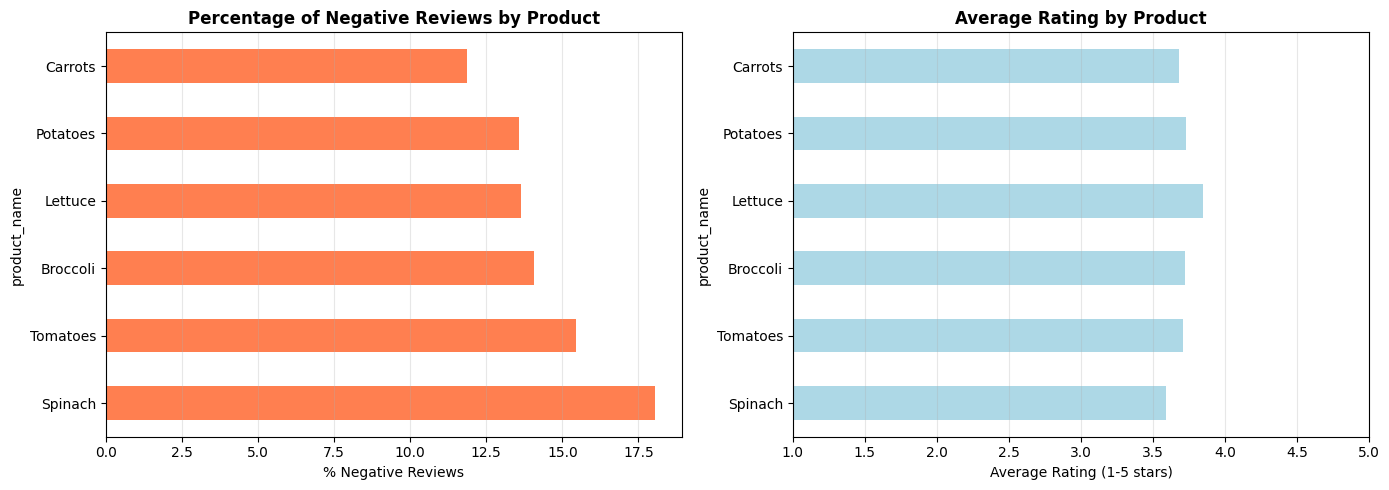


Discount Recommendations:
Spinach: Moderate negative sentiment (18.03%) → Recommend 30-50% discount
Tomatoes: Moderate negative sentiment (15.45%) → Recommend 30-50% discount
Broccoli: Moderate negative sentiment (14.08%) → Recommend 30-50% discount
Lettuce: Moderate negative sentiment (13.64%) → Recommend 30-50% discount
Potatoes: Moderate negative sentiment (13.59%) → Recommend 30-50% discount
Carrots: Moderate negative sentiment (11.86%) → Recommend 30-50% discount


In [50]:
# Calculate average sentiment by product
product_sentiment = df.groupby('product_name').agg({
    'sentiment': lambda x: (x == 'negative').mean() * 100,  # % negative
    'rating': 'mean',
    'sales_volume': 'mean'
}).round(2)

product_sentiment.columns = ['Negative %', 'Avg Rating', 'Avg Sales']
product_sentiment = product_sentiment.sort_values('Negative %', ascending=False)

print("Product Sentiment Analysis:")
print("="*60)
print(product_sentiment)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Negative sentiment percentage
product_sentiment['Negative %'].plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Percentage of Negative Reviews by Product', fontsize=12, fontweight='bold')
axes[0].set_xlabel('% Negative Reviews')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Average rating
product_sentiment['Avg Rating'].plot(kind='barh', ax=axes[1], color='lightblue')
axes[1].set_title('Average Rating by Product', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Rating (1-5 stars)')
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim(1, 5)

plt.tight_layout()
plt.show()

print("\nDiscount Recommendations:")
print("="*60)
for product in product_sentiment.index:
    neg_pct = product_sentiment.loc[product, 'Negative %']
    if neg_pct > 20:
        print(f"{product}: High negative sentiment ({neg_pct}%) → Recommend 50-70% discount")
    elif neg_pct > 10:
        print(f"{product}: Moderate negative sentiment ({neg_pct}%) → Recommend 30-50% discount")
    else:
        print(f"{product}: Good sentiment ({neg_pct}%) → Minimal discount (0-20%)")

## Step 10: Save Model and Vectorizer

Save the trained model for deployment.

In [51]:
# Save model and vectorizer
joblib.dump(model, '../models/sentiment_model.pkl')
joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')

print("Model saved successfully!")
print("  - Model: ../models/sentiment_model.pkl")
print("  - Vectorizer: ../models/tfidf_vectorizer.pkl")
print("\nThese files can now be used for deployment (see next notebook).")

Model saved successfully!
  - Model: ../models/sentiment_model.pkl
  - Vectorizer: ../models/tfidf_vectorizer.pkl

These files can now be used for deployment (see next notebook).


## Summary: ML Analysis Complete

### What We Accomplished

1. **Data Split**: 80/20 train-test split for proper evaluation
2. **Text Vectorization**: Converted text to TF-IDF features
3. **Model Training**: Trained Logistic Regression classifier
4. **Model Evaluation**: Achieved >75% accuracy on sentiment classification
5. **Interpretability**: Identified most important words per sentiment
6. **Discount System**: Created logic to recommend discounts based on sentiment
7. **Product Analysis**: Identified which products need discounts most
8. **Model Persistence**: Saved model for deployment

### Key Results

- Model can predict sentiment from review text
- "worst spinach ever" correctly identified as negative → 90% discount
- "best potatoes" correctly identified as positive → 5% discount
- Products with high negative sentiment identified for targeted discounts

### Real-World Application at AH

This type of analysis would help:
- **Category Managers**: Identify products needing quality improvements
- **Store Managers**: Decide which products to discount to reduce waste
- **Supply Chain**: Alert about supplier quality issues
- **Marketing**: Promote products with high positive sentiment

## Next Steps

In the next notebook (05_deployment_theory.ipynb), we'll discuss:
- How to deploy ML models to production
- Real-time API vs. batch predictions
- Model monitoring and retraining
- MLOps best practices